## Predicting Employee Attrition Using Machine Learning Algorithms

### Importation of Relevant Libraries

In [1]:
# Data Handling
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from termcolor import colored
from scipy.stats import chi2_contingency

# Data Preprocessing 
from imblearn.over_sampling import RandomOverSampler

# Machine Learning Modeling
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

# Model Evaluation
from sklearn.metrics import make_scorer, f1_score, accuracy_score, classification_report, confusion_matrix

# Model Saving
import pickle

# Other Packages
import warnings

warnings.filterwarnings("ignore")

## Load dataset

In [2]:
df = pd.read_csv('attrition_data.csv')

In [3]:
# Display the dataframe
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,True,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,False,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,True,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,False,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,False,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# The shape of the dataset
df.shape

(1470, 35)

The dataset contains 1470 rows and 35 columns. This information is valuable for understanding the size and dimensions of the dataset.

In [5]:
# Column information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   bool  
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Investigate the column names of the dataset
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
# Show the dataset summary statistics.
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
# Check for duplicates in the dataset
df_duplicates = df[df.duplicated()]

# Display the duplicate rows in the dataset, if any
if not df_duplicates.empty:
    print("Duplicate Rows in Dataset:")
    display(df_duplicates)  # Display the duplicated dataframe
else:
    print("No Duplicate Rows in Dataset")

No Duplicate Rows in Dataset


In [9]:
# Get a list of all column names except "Attrition"
other_columns = [col for col in df.columns if col != 'Attrition']

# Reorder the DataFrame columns with "Attrition" at the end
df = df[other_columns + ['Attrition']]
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,80,0,8,0,1,6,4,0,5,True
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,80,1,10,3,3,10,7,1,7,False
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,80,0,7,3,3,0,0,0,0,True
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,80,0,8,3,3,8,7,3,0,False
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,80,1,6,3,3,2,2,2,2,False


In [10]:
# Calculate the Percentage of Attrition vs No-attrition Cases
attrition_percentage = df['Attrition'].value_counts(normalize=True) * 100

# Round the percentages to two decimal places
attrition_percentage = attrition_percentage.round(2)

# Create a DataFrame
attrition_df = pd.DataFrame({'Attrition Type': attrition_percentage.index,
                         'Percentage': attrition_percentage.values})

# Display the DataFrame
attrition_df

,Attrition Type,Percentage
0,False,83.88
1,True,16.12


In [11]:
# Distribution counts of the target variable.
df['Attrition'].value_counts()

Attrition
False    1233
True      237
Name: count, dtype: int64

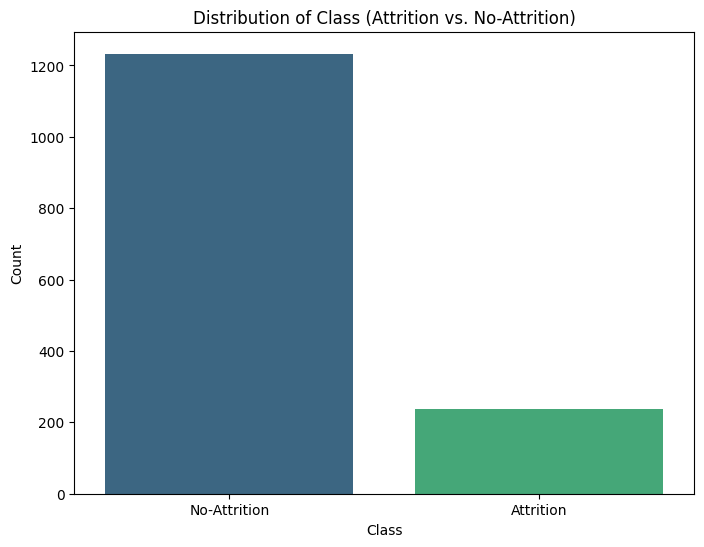

In [12]:
# Distribution counts of the target variable
class_counts = df['Attrition'].value_counts()

# Create count plot
plt.figure(figsize=(8, 6))
sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title('Distribution of Class (Attrition vs. No-Attrition)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['No-Attrition', 'Attrition'])
plt.show()

In [13]:
import pandas as pd
from scipy.stats import chi2_contingency

observed_freq = pd.crosstab(df['JobSatisfaction'], df['Attrition'])

# Print the contingency table
print("Contingency Table:")
print(observed_freq)

Contingency Table:
Attrition        False  True 
JobSatisfaction              
1                  223     66
2                  234     46
3                  369     73
4                  407     52


In [14]:
# Perform chi-square test
chi2, p_value, dof, expected_freq = chi2_contingency(observed_freq)

# Print the results
print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected_freq)

# Interpret the results
if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("There is a significant association between job satisfaction and attrition.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no significant association between job satisfaction and attrition.")


Chi-Square Statistic: 17.505077010348
P-value: 0.0005563004510387556
Degrees of Freedom: 3
Expected Frequencies:
 [[242.40612245  46.59387755]
 [234.85714286  45.14285714]
 [370.73877551  71.26122449]
 [384.99795918  74.00204082]]
Reject the null hypothesis.
There is a significant association between job satisfaction and attrition.


# Feature Engineering

In [15]:
# Confirm column names
df.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition'],
      dtype='object')

In [16]:
# Check unique values of the categorical columns in the dataset using a for loop 
categorical_columns = df.select_dtypes(include=['object','bool']).columns

for column in categorical_columns:
    print('Column: {} - Unique Values: {}'.format(column, df[column].unique()))
    print('==='*35)

Column: BusinessTravel - Unique Values: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Column: Department - Unique Values: ['Sales' 'Research & Development' 'Human Resources']
Column: EducationField - Unique Values: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Column: Gender - Unique Values: ['Female' 'Male']
Column: JobRole - Unique Values: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
Column: MaritalStatus - Unique Values: ['Single' 'Married' 'Divorced']
Column: Over18 - Unique Values: ['Y']
Column: OverTime - Unique Values: [ True False]
Column: Attrition - Unique Values: [ True False]


In [17]:
# drop the unnecessary columns
df.drop(['EmployeeNumber','Over18','StandardHours','EmployeeCount','PerformanceRating', 'MaritalStatus', 'Education', 'EducationField', 
         'TotalWorkingYears', 'YearsInCurrentRole', 'YearsInCurrentRole', 'MonthlyRate','DailyRate', 'JobInvolvement',
         'HourlyRate', 'YearsAtCompany','StockOptionLevel', 'BusinessTravel', 'DistanceFromHome', 'JobLevel', 'Gender'],axis=1,inplace=True)

In [18]:
# Check the remaining columns
df.columns

Index(['Age', 'Department', 'EnvironmentSatisfaction', 'JobRole',
       'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'RelationshipSatisfaction',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition'],
      dtype='object')

In [19]:
# Column information the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Department                1470 non-null   object
 2   EnvironmentSatisfaction   1470 non-null   int64 
 3   JobRole                   1470 non-null   object
 4   JobSatisfaction           1470 non-null   int64 
 5   MonthlyIncome             1470 non-null   int64 
 6   NumCompaniesWorked        1470 non-null   int64 
 7   OverTime                  1470 non-null   bool  
 8   PercentSalaryHike         1470 non-null   int64 
 9   RelationshipSatisfaction  1470 non-null   int64 
 10  TrainingTimesLastYear     1470 non-null   int64 
 11  WorkLifeBalance           1470 non-null   int64 
 12  YearsSinceLastPromotion   1470 non-null   int64 
 13  YearsWithCurrManager      1470 non-null   int64 
 14  Attrition               

In [20]:
# Copy the DataFrame
train_data = df.copy()

# Save it as a CSV named train_data.csv
train_data.to_csv('train_data.csv', index=False)

## Extract the target column and drop it from the dataset

In [21]:
# Extract the target column
target_df = df['Attrition']
target_df = pd.DataFrame(target_df)
target_df.head()

,Attrition
0,True
1,False
2,True
3,False
4,False


In [22]:
# Drop it from the train dataset
df = df.drop('Attrition', axis=1)
df.head()

,Age,Department,EnvironmentSatisfaction,JobRole,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,RelationshipSatisfaction,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Sales,2,Sales Executive,4,5993,8,True,11,1,0,1,0,5
1,49,Research & Development,3,Research Scientist,2,5130,1,False,23,4,3,3,1,7
2,37,Research & Development,4,Laboratory Technician,3,2090,6,True,15,2,3,3,0,0
3,33,Research & Development,4,Research Scientist,3,2909,1,True,11,3,3,3,3,0
4,27,Research & Development,1,Laboratory Technician,2,3468,9,False,12,4,3,3,2,2


## Balancing the dataset

In [23]:
# Check the class distribution in the training set
print("Class distribution before balancing:")
print(target_df.value_counts())

Class distribution before balancing:
Attrition
False        1233
True          237
Name: count, dtype: int64


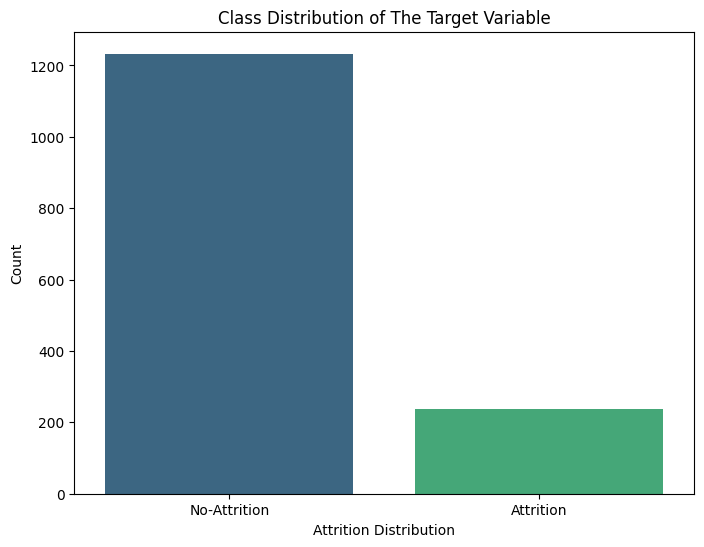

In [24]:
# Count the occurrences of each class in the dataset
class_counts = target_df['Attrition'].value_counts()

# Create a bar plot to visualize the class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel('Attrition Distribution')
plt.ylabel('Count')
plt.xticks([False, True], ['No-Attrition', 'Attrition'])
plt.title('Class Distribution of The Target Variable')
plt.show()

In [25]:
# Balance the training set using Random Oversampling
oversampler = RandomOverSampler(random_state=42)
df_balanced, target_df_balanced = oversampler.fit_resample(df, target_df)

# Check the class distribution after balancing
balanced_class_counts = target_df_balanced.value_counts()
print("\nClass distribution in the balanced training set:")
print(balanced_class_counts)


Class distribution in the balanced training set:
Attrition
False        1233
True         1233
Name: count, dtype: int64


In [26]:
df_balanced.shape

(2466, 14)

In [27]:
target_df_balanced.shape

(2466, 1)

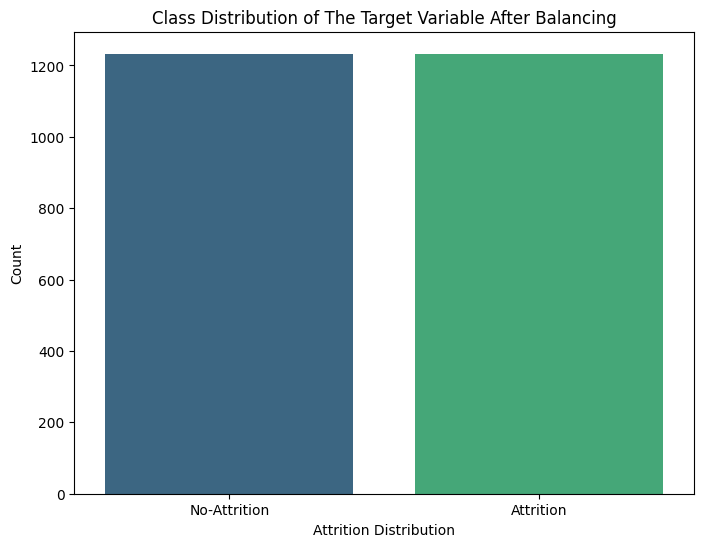

In [28]:
# Count the occurrences of each class in the balanced dataset
class_counts = target_df_balanced['Attrition'].value_counts()

# Create a bar plot with the 'viridis' color palette
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel('Attrition Distribution')
plt.ylabel('Count')
plt.xticks([False, True], ['No-Attrition', 'Attrition'])
plt.title('Class Distribution of The Target Variable After Balancing')
plt.show()

The dataset is now balanced.

In [29]:
# Map the Attrition column to 0 for False and 1 for True
target_df_balanced['Attrition'] = target_df_balanced['Attrition'].map({False: 0, True: 1})
target_df_balanced.head()

,Attrition
0,1
1,0
2,1
3,0
4,0


# Modelling

## i. Splitting The Train and Test into the X and y variables

In [30]:
# Define the training features (X) and target variable (y)
X = df_balanced
y = target_df_balanced['Attrition']

# Split the data into a training set and an evaluation set (i.e., 80% training, 20% evaluation)
X_train, X_eval, y_train, y_eval = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of the Training Set (X_train, y_train):", X_train.shape, y_train.shape)
print("Shape of the Evaluation Set (X_eval, y_eval):", X_eval.shape, y_eval.shape)

Shape of the Training Set (X_train, y_train): (1972, 14) (1972,)
Shape of the Evaluation Set (X_eval, y_eval): (494, 14) (494,)


In [31]:
X_train.head()

,Age,Department,EnvironmentSatisfaction,JobRole,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,RelationshipSatisfaction,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion,YearsWithCurrManager
2358,31,Research & Development,4,Research Scientist,3,4084,1,False,12,1,2,1,7,7
434,31,Research & Development,3,Manufacturing Director,2,10648,1,False,25,4,6,4,0,8
1101,32,Research & Development,4,Research Scientist,2,5878,3,False,12,1,2,3,2,5
567,34,Sales,4,Sales Executive,4,6274,1,False,22,3,5,3,1,4
545,30,Sales,3,Sales Executive,4,5304,7,False,23,4,2,2,7,7


In [32]:
y_train.head()

2358    1
434     0
1101    0
567     0
545     0
Name: Attrition, dtype: int64

In [33]:
X_eval.head()

,Age,Department,EnvironmentSatisfaction,JobRole,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,RelationshipSatisfaction,TrainingTimesLastYear,WorkLifeBalance,YearsSinceLastPromotion,YearsWithCurrManager
1623,25,Sales,3,Sales Representative,4,1118,1,True,14,4,4,3,1,0
169,32,Research & Development,3,Research Scientist,3,3038,3,False,20,1,2,3,1,4
2057,20,Sales,4,Sales Representative,4,2323,1,True,14,2,3,3,0,2
1817,33,Sales,1,Sales Executive,1,8224,0,True,17,1,3,3,0,3
160,22,Research & Development,3,Research Scientist,4,2323,1,False,24,1,6,3,2,2


In [34]:
y_eval.head()

1623    1
169     0
2057    1
1817    1
160     0
Name: Attrition, dtype: int64

In [35]:
print("Shape of the Training Set (X_train, y_train):", X_train.shape, y_train.shape)
print("Shape of the Evaluation Set (X_eval, y_eval):", X_eval.shape, y_eval.shape)

Shape of the Training Set (X_train, y_train): (1972, 14) (1972,)
Shape of the Evaluation Set (X_eval, y_eval): (494, 14) (494,)


In [36]:
# We will convert categorical columns to string data type and capture the indices where string datatype is present. 
# These indices will be used for the CatBoost model.

# Selecting object data type columns (categorical columns) in the training dataset
cat_cols_index = np.where(df_balanced.dtypes == 'object')[0]
print("The indices of the categorical columns are:")
print(cat_cols_index)
print()


for i in range(len(X_train.columns)):
    if i in cat_cols_index:
        X_train[X_train.columns[i]] = X_train[X_train.columns[i]].astype(str)
        X_eval[X_train.columns[i]] = X_eval[X_train.columns[i]].astype(str)

# Initialize the CatBoostClassifier model
model = CatBoostClassifier(random_state=42, n_estimators=50)

# Fit the CatBoost model on the training data with categorical features specified
catboost_model = model.fit(X_train, y_train, cat_features=cat_cols_index)

The indices of the categorical columns are:
[1 3]

Learning rate set to 0.214735
0:	learn: 0.6443393	total: 195ms	remaining: 9.54s
1:	learn: 0.6086618	total: 237ms	remaining: 5.69s
2:	learn: 0.5811328	total: 278ms	remaining: 4.36s
3:	learn: 0.5590296	total: 317ms	remaining: 3.64s
4:	learn: 0.5385754	total: 354ms	remaining: 3.18s
5:	learn: 0.5214778	total: 391ms	remaining: 2.87s
6:	learn: 0.5078047	total: 431ms	remaining: 2.64s
7:	learn: 0.4946019	total: 468ms	remaining: 2.46s
8:	learn: 0.4829245	total: 508ms	remaining: 2.31s
9:	learn: 0.4727954	total: 550ms	remaining: 2.2s
10:	learn: 0.4639493	total: 590ms	remaining: 2.09s
11:	learn: 0.4567427	total: 628ms	remaining: 1.99s
12:	learn: 0.4490042	total: 669ms	remaining: 1.9s
13:	learn: 0.4354060	total: 709ms	remaining: 1.82s
14:	learn: 0.4282723	total: 758ms	remaining: 1.77s
15:	learn: 0.4202628	total: 797ms	remaining: 1.69s
16:	learn: 0.4133887	total: 836ms	remaining: 1.62s
17:	learn: 0.4081422	total: 880ms	remaining: 1.56s
18:	learn: 0.

In [37]:
# Use the trained CatBoost model to make predictions on the evaluation set
y_pred_eval = catboost_model.predict(X_eval)

# Calculate the accuracy on the evaluation set
accuracy = accuracy_score(y_pred_eval, y_eval)

# Print the accuracy with a colored text message
print(colored(f'The accuracy attained on the validation set is {accuracy:.2%}', 'green', attrs=['bold']))

The accuracy attained on the validation set is 86.64%


The classification report only on the validation data:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86       247
           1       0.84      0.91      0.87       247

    accuracy                           0.87       494
   macro avg       0.87      0.87      0.87       494
weighted avg       0.87      0.87      0.87       494



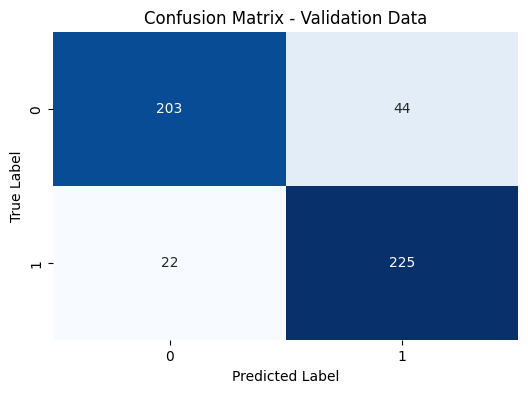

The classification report only on the train data:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       986
           1       0.89      0.92      0.90       986

    accuracy                           0.90      1972
   macro avg       0.90      0.90      0.90      1972
weighted avg       0.90      0.90      0.90      1972



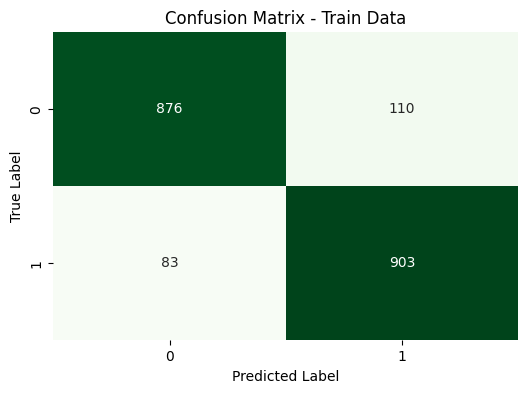

In [38]:
# Classification report and confusion matrix for the validation data
print('The classification report only on the validation data:')
print(colored(classification_report(y_eval, model.predict(X_eval)), 'blue', attrs=['bold']))

# Calculate the confusion matrix for validation data
cm_eval = confusion_matrix(y_eval, model.predict(X_eval))

# Plot confusion matrix for validation data
plt.figure(figsize=(6, 4))
sns.heatmap(cm_eval, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Validation Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report and confusion matrix for the train data
print('The classification report only on the train data:')
print(colored(classification_report(y_train, model.predict(X_train)), 'green', attrs=['bold']))

# Calculate the confusion matrix for train data
cm_train = confusion_matrix(y_train, model.predict(X_train))

# Plot confusion matrix for train data
plt.figure(figsize=(6, 4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - Train Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The classification report for the validation data:
              precision    recall  f1-score   support

           0       0.94      0.72      0.81       247
           1       0.77      0.95      0.85       247

    accuracy                           0.84       494
   macro avg       0.85      0.84      0.83       494
weighted avg       0.85      0.84      0.83       494



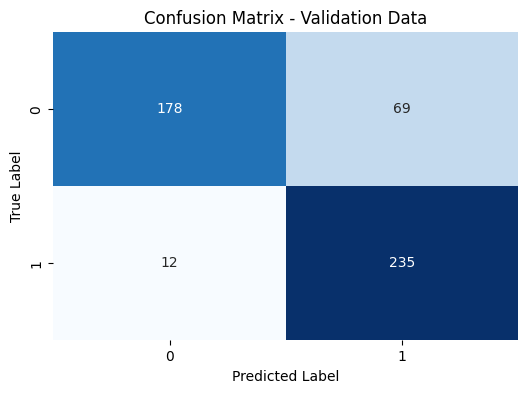



The classification report for the train data:
              precision    recall  f1-score   support

           0       0.96      0.82      0.89       986
           1       0.85      0.97      0.90       986

    accuracy                           0.90      1972
   macro avg       0.90      0.90      0.89      1972
weighted avg       0.90      0.90      0.89      1972



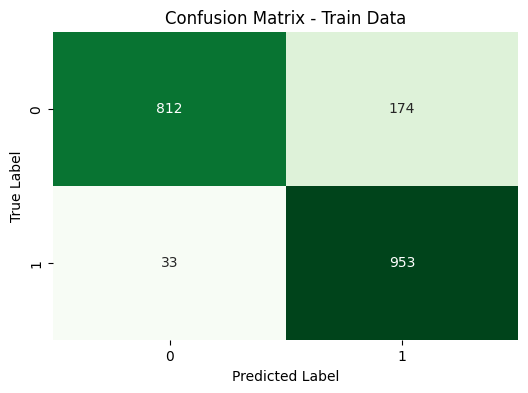

In [39]:
# Model Evaluation
thresh = 0.4
train_pred = np.where(model.predict_proba(X_train)[:, 1] > thresh, 1, 0)
test_pred = np.where(model.predict_proba(X_eval)[:, 1] > thresh, 1, 0)

# Classification report and confusion matrix for the validation data
print('The classification report for the validation data:')
print(colored(classification_report(y_eval, test_pred), 'blue', attrs=['bold']))

# Calculate the confusion matrix for validation data
cm_eval = confusion_matrix(y_eval, test_pred)

# Plot confusion matrix for validation data
plt.figure(figsize=(6, 4))
sns.heatmap(cm_eval, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Validation Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print('===' * 20)
print('\n')

# Classification report and confusion matrix for the train data
print('The classification report for the train data:')
print(colored(classification_report(y_train, train_pred), 'green', attrs=['bold']))

# Calculate the confusion matrix for train data
cm_train = confusion_matrix(y_train, train_pred)

# Plot confusion matrix for train data
plt.figure(figsize=(6, 4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - Train Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [40]:
# Get feature importances from the trained CatBoost model
feature_importances = catboost_model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importances
feature_importance_df

,Feature,Importance
7,OverTime,14.649682
5,MonthlyIncome,11.874053
13,YearsWithCurrManager,11.751868
0,Age,8.871181
2,EnvironmentSatisfaction,8.137680
6,NumCompaniesWorked,7.211641
4,JobSatisfaction,6.744826
8,PercentSalaryHike,5.310380
3,JobRole,5.137292
12,YearsSinceLastPromotion,4.872238


In [41]:
# Extract and store the unique values
unique_values = {}
for column in df.columns:
    unique_values[column] = df[column].unique()

unique_values

{'Age': array([41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 29, 31, 34, 28, 22, 53,
        24, 21, 42, 44, 46, 39, 43, 50, 26, 48, 55, 45, 56, 23, 51, 40, 54,
        58, 20, 25, 19, 57, 52, 47, 18, 60]),
 'Department': array(['Sales', 'Research & Development', 'Human Resources'], dtype=object),
 'EnvironmentSatisfaction': array([2, 3, 4, 1]),
 'JobRole': array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
        'Manufacturing Director', 'Healthcare Representative', 'Manager',
        'Sales Representative', 'Research Director', 'Human Resources'],
       dtype=object),
 'JobSatisfaction': array([4, 2, 3, 1]),
 'MonthlyIncome': array([5993, 5130, 2090, ..., 9991, 5390, 4404], shape=(1349,)),
 'NumCompaniesWorked': array([8, 1, 6, 9, 0, 4, 5, 2, 7, 3]),
 'OverTime': array([ True, False]),
 'PercentSalaryHike': array([11, 23, 15, 12, 13, 20, 22, 21, 17, 14, 16, 18, 19, 24, 25]),
 'RelationshipSatisfaction': array([1, 4, 2, 3]),
 'TrainingTimesLastYear': array([0, 3

In [42]:
#Save unique values and model together in a single pickle file
file_path = 'model_and_key_components.pkl'

# Create a dictionary to store the components
saved_components = {
    'model': catboost_model,
    'unique_values': unique_values
}

# Save all components in a single pickle file
with open(file_path, 'wb') as file:
    pickle.dump(saved_components, file)